In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import pandas as pd

CASES_URL = (
    "https://storage.googleapis.com/"
    "dx-scin-public-data/dataset/scin_cases.csv"
)

LABELS_URL = (
    "https://storage.googleapis.com/"
    "dx-scin-public-data/dataset/scin_labels.csv"
)

cases = pd.read_csv(CASES_URL)
labels = pd.read_csv(LABELS_URL)

print("Cases:", cases.shape)
print("Labels:", labels.shape)

print("\nCASE COLUMNS:")
print(cases.columns.tolist())

print("\nLABEL COLUMNS:")
print(labels.columns.tolist())

Cases: (5033, 57)
Labels: (5033, 17)

CASE COLUMNS:
['case_id', 'source', 'release', 'year', 'age_group', 'sex_at_birth', 'fitzpatrick_skin_type', 'race_ethnicity_american_indian_or_alaska_native', 'race_ethnicity_asian', 'race_ethnicity_black_or_african_american', 'race_ethnicity_hispanic_latino_or_spanish_origin', 'race_ethnicity_middle_eastern_or_north_african', 'race_ethnicity_native_hawaiian_or_pacific_islander', 'race_ethnicity_white', 'race_ethnicity_other_race', 'race_ethnicity_prefer_not_to_answer', 'textures_raised_or_bumpy', 'textures_flat', 'textures_rough_or_flaky', 'textures_fluid_filled', 'body_parts_head_or_neck', 'body_parts_arm', 'body_parts_palm', 'body_parts_back_of_hand', 'body_parts_torso_front', 'body_parts_torso_back', 'body_parts_genitalia_or_groin', 'body_parts_buttocks', 'body_parts_leg', 'body_parts_foot_top_or_side', 'body_parts_foot_sole', 'body_parts_other', 'condition_symptoms_bothersome_appearance', 'condition_symptoms_bleeding', 'condition_symptoms_inc

In [3]:
print("RELATED CATEGORIES:\n")

print(
    cases["related_category"]
    .value_counts(dropna=False)
)

RELATED CATEGORIES:

related_category
RASH                       2876
NaN                        1254
OTHER_ISSUE_DESCRIPTION     414
LOOKS_HEALTHY               290
ACNE                         74
GROWTH_OR_MOLE               45
PIGMENTARY_PROBLEM           37
NAIL_PROBLEM                 20
OTHER_HAIR_PROBLEM           12
HAIR_LOSS                    11
Name: count, dtype: int64


In [4]:
label_col = "weighted_skin_condition_label"

print(
    labels[label_col]
    .dropna()
    .head(20)
    .to_string(index=False)
)

{'Inflicted skin lesions': 0.41, 'Eczema': 0.41...
{'Prurigo nodularis': 0.41, 'SCC/SCCIS': 0.41, ...
{'Impetigo': 0.55, 'Herpes Zoster': 0.23, 'Bull...
                                                {}
{'Lichen planus/lichenoid eruption': 0.33, 'Fol...
{'Drug Rash': 0.41, 'Viral Exanthem': 0.41, 'Ec...
{'Urticaria': 0.6, 'Leukocytoclastic Vasculitis...
{'Basal Cell Carcinoma': 0.55, 'Inflicted skin ...
{'Eczema': 0.67, 'Psoriasis': 0.11, 'Acute and ...
                                  {'Purpura': 1.0}
{'Eczema': 0.55, 'Drug Rash': 0.23, 'Allergic C...
                                {'Urticaria': 1.0}
                                                {}
{'Skin infection': 0.33, 'Scabies': 0.33, 'Moll...
                                                {}
{'Tinea Versicolor': 0.46, 'Urticaria': 0.35, '...
                                                {}
{'Stasis Dermatitis': 0.33, 'Eczema': 0.33, 'Al...
{'Tinea Versicolor': 0.61, 'Seborrheic Dermatit...
{'Lichen planus/lichenoid erupt

In [5]:
import ast
from collections import Counter

condition_counts = Counter()

for value in labels["weighted_skin_condition_label"].dropna():
    try:
        parsed = ast.literal_eval(value)

        if isinstance(parsed, dict):
            for condition in parsed.keys():
                condition_counts[condition] += 1

    except Exception:
        pass

print("Number of unique dermatologist conditions:", len(condition_counts))

print("\nTOP CONDITIONS:")
for condition, count in condition_counts.most_common(50):
    print(f"{condition}: {count}")

Number of unique dermatologist conditions: 370

TOP CONDITIONS:
Eczema: 1056
Allergic Contact Dermatitis: 873
Insect Bite: 403
Urticaria: 332
Psoriasis: 308
Folliculitis: 268
Irritant Contact Dermatitis: 249
Tinea: 206
Drug Rash: 148
Herpes Zoster: 142
Herpes Simplex: 141
Acute dermatitis, NOS: 124
Impetigo: 121
Hypersensitivity: 113
Leukocytoclastic Vasculitis: 99
Acne: 98
Pigmented purpuric eruption: 98
Lichen planus/lichenoid eruption: 89
Viral Exanthem: 82
Pityriasis rosea: 80
Lichen Simplex Chronicus: 78
Stasis Dermatitis: 70
CD - Contact dermatitis: 70
Scabies: 63
Molluscum Contagiosum: 63
Keratosis pilaris: 61
Granuloma annulare: 59
Tinea Versicolor: 53
Rosacea: 52
O/E - ecchymoses present: 50
Abrasion, scrape, or scab: 48
Acute and chronic dermatitis: 47
Seborrheic Dermatitis: 46
Photodermatitis: 43
Abscess: 41
Verruca vulgaris: 40
Cellulitis: 39
SCC/SCCIS: 37
Purpura: 36
Miliaria: 36
Erythema multiforme: 33
Syphilis: 32
Cutaneous lupus: 31
Intertrigo: 31
Inflicted skin lesions

In [6]:
targets = [
    "Acne",
    "Post-Inflammatory hyperpigmentation",
    "Rosacea",
    "Eczema",
    "Psoriasis",
    "Folliculitis",
    "Seborrheic Dermatitis",
    "Keratosis pilaris",
]

print("DERMAWISE CANDIDATE CONDITIONS\n")
print("-" * 55)

for target in targets:
    print(f"{target:<40} {condition_counts.get(target, 0)}")

DERMAWISE CANDIDATE CONDITIONS

-------------------------------------------------------
Acne                                     98
Post-Inflammatory hyperpigmentation      28
Rosacea                                  52
Eczema                                   1056
Psoriasis                                308
Folliculitis                             268
Seborrheic Dermatitis                    46
Keratosis pilaris                        61


In [7]:
print("CASES COLUMNS:")
for col in cases.columns:
    print(col)

print("\n" + "=" * 60)

print("LABELS COLUMNS:")
for col in labels.columns:
    print(col)

print("\n" + "=" * 60)

print("FIRST LABEL ROW:")
display(labels.head(1))

print("\nFIRST CASE ROW:")
display(cases.head(1))

CASES COLUMNS:
case_id
source
release
year
age_group
sex_at_birth
fitzpatrick_skin_type
race_ethnicity_american_indian_or_alaska_native
race_ethnicity_asian
race_ethnicity_black_or_african_american
race_ethnicity_hispanic_latino_or_spanish_origin
race_ethnicity_middle_eastern_or_north_african
race_ethnicity_native_hawaiian_or_pacific_islander
race_ethnicity_white
race_ethnicity_other_race
race_ethnicity_prefer_not_to_answer
textures_raised_or_bumpy
textures_flat
textures_rough_or_flaky
textures_fluid_filled
body_parts_head_or_neck
body_parts_arm
body_parts_palm
body_parts_back_of_hand
body_parts_torso_front
body_parts_torso_back
body_parts_genitalia_or_groin
body_parts_buttocks
body_parts_leg
body_parts_foot_top_or_side
body_parts_foot_sole
body_parts_other
condition_symptoms_bothersome_appearance
condition_symptoms_bleeding
condition_symptoms_increasing_size
condition_symptoms_darkening
condition_symptoms_itching
condition_symptoms_burning
condition_symptoms_pain
condition_symptoms_no

,case_id,dermatologist_gradable_for_skin_condition_1,dermatologist_gradable_for_skin_condition_2,dermatologist_gradable_for_skin_condition_3,dermatologist_skin_condition_on_label_name,dermatologist_skin_condition_confidence,weighted_skin_condition_label,dermatologist_gradable_for_fitzpatrick_skin_type_1,dermatologist_gradable_for_fitzpatrick_skin_type_2,dermatologist_gradable_for_fitzpatrick_skin_type_3,dermatologist_fitzpatrick_skin_type_label_1,dermatologist_fitzpatrick_skin_type_label_2,dermatologist_fitzpatrick_skin_type_label_3,gradable_for_monk_skin_tone_india,gradable_for_monk_skin_tone_us,monk_skin_tone_label_india,monk_skin_tone_label_us
0,-1000600354148496558,DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT,NaN,NaN,"['Inflicted skin lesions', 'Eczema', 'Irritant...","[4, 4, 3]","{'Inflicted skin lesions': 0.41, 'Eczema': 0.4...",YES,NaN,NaN,FST2,NaN,NaN,True,True,2.0,1.0



FIRST CASE ROW:


,case_id,source,release,year,age_group,sex_at_birth,fitzpatrick_skin_type,race_ethnicity_american_indian_or_alaska_native,race_ethnicity_asian,race_ethnicity_black_or_african_american,...,related_category,condition_duration,image_1_path,image_2_path,image_3_path,image_1_shot_type,image_2_shot_type,image_3_shot_type,combined_race,race_ethnicity_two_or_more_after_mitigation
0,-1000600354148496558,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,NaN,NaN,NaN,NaN,...,RASH,ONE_DAY,dataset/images/-3205742176803893704.png,NaN,NaN,CLOSE_UP,NaN,NaN,NaN,NaN


In [8]:
import ast
import pandas as pd

TARGET_CONDITIONS = [
    "Acne",
    "Post-Inflammatory hyperpigmentation",
    "Rosacea",
    "Eczema",
    "Psoriasis",
    "Folliculitis",
    "Seborrheic Dermatitis",
    "Keratosis pilaris",
]

def get_primary_condition(value):
    try:
        if isinstance(value, str):
            value = ast.literal_eval(value)

        if isinstance(value, dict) and len(value) > 0:
            condition = max(value, key=value.get)
            weight = float(value[condition])
            return pd.Series([condition, weight])

    except Exception:
        pass

    return pd.Series([None, None])


labels[["primary_condition", "primary_weight"]] = (
    labels["weighted_skin_condition_label"]
    .apply(get_primary_condition)
)

# Keep only our candidate conditions
target_labels = labels[
    labels["primary_condition"].isin(TARGET_CONDITIONS)
].copy()

# Connect dermatologist labels to case/image information
common_skin_df = target_labels.merge(
    cases[
        [
            "case_id",
            "image_1_path",
            "image_2_path",
            "image_3_path",
            "image_1_shot_type",
            "image_2_shot_type",
            "image_3_shot_type",
            "related_category",
        ]
    ],
    on="case_id",
    how="inner",
)

print("Total selected cases:", len(common_skin_df))

print("\nPRIMARY CONDITION COUNTS:")
print(
    common_skin_df["primary_condition"]
    .value_counts()
)

print("\nPRIMARY WEIGHT SUMMARY:")
print(
    common_skin_df.groupby("primary_condition")["primary_weight"]
    .agg(["count", "mean", "min", "max"])
    .round(3)
)

Total selected cases: 881

PRIMARY CONDITION COUNTS:
primary_condition
Eczema                                 488
Folliculitis                           142
Psoriasis                              109
Acne                                    61
Keratosis pilaris                       32
Rosacea                                 29
Seborrheic Dermatitis                   14
Post-Inflammatory hyperpigmentation      6
Name: count, dtype: int64

PRIMARY WEIGHT SUMMARY:
                                     count   mean   min   max
primary_condition                                            
Acne                                    61  0.663  0.33  1.00
Eczema                                 488  0.644  0.17  1.00
Folliculitis                           142  0.630  0.22  1.00
Keratosis pilaris                       32  0.608  0.33  1.00
Post-Inflammatory hyperpigmentation      6  0.582  0.50  0.67
Psoriasis                              109  0.554  0.22  1.00
Rosacea                               

In [9]:
CORE_CONDITIONS = [
    "Acne",
    "Eczema",
    "Folliculitis",
    "Psoriasis",
]

core_df = common_skin_df[
    (common_skin_df["primary_condition"].isin(CORE_CONDITIONS))
    & (common_skin_df["primary_weight"] >= 0.50)
].copy()

print("Total high-confidence cases:", len(core_df))

print("\nCASES PER CONDITION:")
print(
    core_df["primary_condition"]
    .value_counts()
)

print("\nWEIGHT SUMMARY:")
print(
    core_df.groupby("primary_condition")["primary_weight"]
    .agg(["count", "mean", "min", "max"])
    .round(3)
)

print("\nNUMBER OF AVAILABLE IMAGE PATHS:")

for condition in CORE_CONDITIONS:
    subset = core_df[
        core_df["primary_condition"] == condition
    ]

    image_count = (
        subset[
            [
                "image_1_path",
                "image_2_path",
                "image_3_path",
            ]
        ]
        .notna()
        .sum()
        .sum()
    )

    print(f"{condition:<20}: {image_count}")

Total high-confidence cases: 589

CASES PER CONDITION:
primary_condition
Eczema          373
Folliculitis    101
Psoriasis        65
Acne             50
Name: count, dtype: int64

WEIGHT SUMMARY:
                   count   mean  min  max
primary_condition                        
Acne                  50  0.723  0.5  1.0
Eczema               373  0.731  0.5  1.0
Folliculitis         101  0.747  0.5  1.0
Psoriasis             65  0.691  0.5  1.0

NUMBER OF AVAILABLE IMAGE PATHS:
Acne                : 100
Eczema              : 802
Folliculitis        : 217
Psoriasis           : 129


In [11]:
image_rows = []

for _, row in core_df.iterrows():
    for i in range(1, 4):
        path_col = f"image_{i}_path"
        shot_col = f"image_{i}_shot_type"

        image_path = row[path_col]

        if pd.notna(image_path):
            image_rows.append({
                "case_id": row["case_id"],
                "image_path": image_path,
                "shot_type": row[shot_col],
                "label": row["primary_condition"],
                "label_weight": row["primary_weight"],
            })

skin_images_df = pd.DataFrame(image_rows)

print("Total image records:", len(skin_images_df))

print("\nIMAGES PER CLASS:")
print(
    skin_images_df["label"]
    .value_counts()
)

print("\nSHOT TYPES:")
print(
    skin_images_df["shot_type"]
    .value_counts(dropna=False)
)

print("\nFIRST 10 RECORDS:")
display(skin_images_df.head(10))

print("\nDuplicate image paths:",
      skin_images_df["image_path"].duplicated().sum())

print("Unique cases:",
      skin_images_df["case_id"].nunique())

Total image records: 1248

IMAGES PER CLASS:
label
Eczema          802
Folliculitis    217
Psoriasis       129
Acne            100
Name: count, dtype: int64

SHOT TYPES:
shot_type
CLOSE_UP       589
AT_AN_ANGLE    369
AT_DISTANCE    290
Name: count, dtype: int64

FIRST 10 RECORDS:


,case_id,image_path,shot_type,label,label_weight
0,-101827005996397499,dataset/images/-217828380359571871.png,CLOSE_UP,Eczema,0.67
1,-101827005996397499,dataset/images/-4055728304670056584.png,AT_AN_ANGLE,Eczema,0.67
2,-1031911667791094656,dataset/images/-3712452163219577722.png,AT_DISTANCE,Eczema,0.55
3,-1031911667791094656,dataset/images/-983426416985154601.png,AT_AN_ANGLE,Eczema,0.55
4,-1031911667791094656,dataset/images/8538075517728087299.png,CLOSE_UP,Eczema,0.55
5,-1079717215777778516,dataset/images/-3060870142909393201.png,CLOSE_UP,Eczema,1.00
6,-1120481478267460560,dataset/images/-3933475004882152757.png,CLOSE_UP,Eczema,1.00
7,-1120481478267460560,dataset/images/-6233451743223829948.png,AT_DISTANCE,Eczema,1.00
8,-1120481478267460560,dataset/images/-764324206369620251.png,AT_AN_ANGLE,Eczema,1.00
9,-1131745754224368828,dataset/images/4174575629707577584.png,CLOSE_UP,Eczema,0.50



Duplicate image paths: 4
Unique cases: 589


In [12]:
# Remove duplicate image paths
skin_images_df = (
    skin_images_df
    .drop_duplicates(subset=["image_path"])
    .reset_index(drop=True)
)

print("FINAL CLEAN DATASET")
print("=" * 50)

print("Total images:", len(skin_images_df))
print("Unique image paths:", skin_images_df["image_path"].nunique())
print("Unique cases:", skin_images_df["case_id"].nunique())

print("\nIMAGES PER CLASS:")
print(skin_images_df["label"].value_counts())

print("\nCASES PER CLASS:")
print(
    skin_images_df
    .groupby("label")["case_id"]
    .nunique()
    .sort_values(ascending=False)
)

print("\nSHOT TYPES:")
print(skin_images_df["shot_type"].value_counts(dropna=False))

# Save our manifest
skin_images_df.to_csv(
    "/content/dermawise_common_skin_manifest.csv",
    index=False
)

print("\nManifest saved successfully.")

FINAL CLEAN DATASET
Total images: 1244
Unique image paths: 1244
Unique cases: 586

IMAGES PER CLASS:
label
Eczema          802
Folliculitis    215
Psoriasis       129
Acne             98
Name: count, dtype: int64

CASES PER CLASS:
label
Eczema          373
Folliculitis    100
Psoriasis        65
Acne             48
Name: case_id, dtype: int64

SHOT TYPES:
shot_type
CLOSE_UP       586
AT_AN_ANGLE    368
AT_DISTANCE    290
Name: count, dtype: int64

Manifest saved successfully.


In [13]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [14]:
from pathlib import Path

COMMON_SKIN_DIR = Path(
    "/content/drive/MyDrive/DermaWise/data/scin_common_skin"
)

COMMON_SKIN_DIR.mkdir(parents=True, exist_ok=True)

print("Saving images to:")
print(COMMON_SKIN_DIR)

Saving images to:
/content/drive/MyDrive/DermaWise/data/scin_common_skin


In [15]:
manifest_path = (
    "/content/drive/MyDrive/DermaWise/data/"
    "dermawise_common_skin_manifest.csv"
)

skin_images_df.to_csv(
    manifest_path,
    index=False
)

print("Manifest saved to:")
print(manifest_path)

Manifest saved to:
/content/drive/MyDrive/DermaWise/data/dermawise_common_skin_manifest.csv


In [16]:
import requests
from pathlib import Path
from tqdm.auto import tqdm

BASE_URL = "https://storage.googleapis.com/dx-scin-public-data/"
DOWNLOAD_DIR = Path(
    "/content/drive/MyDrive/DermaWise/data/scin_common_skin"
)

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

downloaded = 0
already_exists = 0
failed = []

for _, row in tqdm(
    skin_images_df.iterrows(),
    total=len(skin_images_df),
    desc="Downloading SCIN images"
):
    image_path = row["image_path"]

    # Example:
    # dataset/images/123456.png
    url = BASE_URL + image_path

    filename = Path(image_path).name
    save_path = DOWNLOAD_DIR / filename

    # Don't download again if Colab is restarted
    if save_path.exists() and save_path.stat().st_size > 0:
        already_exists += 1
        continue

    try:
        response = requests.get(
            url,
            timeout=30
        )

        if response.status_code == 200:
            save_path.write_bytes(response.content)
            downloaded += 1
        else:
            failed.append({
                "image_path": image_path,
                "status": response.status_code
            })

    except Exception as e:
        failed.append({
            "image_path": image_path,
            "status": str(e)
        })

print("\nDOWNLOAD COMPLETE")
print("=" * 50)
print("Newly downloaded:", downloaded)
print("Already existed:", already_exists)
print("Failed:", len(failed))
print("Files currently in folder:", len(list(DOWNLOAD_DIR.glob("*"))))

if failed:
    print("\nFIRST FAILED DOWNLOADS:")
    for item in failed[:10]:
        print(item)


DOWNLOAD COMPLETE
Newly downloaded: 1244
Already existed: 0
Failed: 0
Files currently in folder: 1244


In [17]:
from PIL import Image

valid_images = []
invalid_images = []

for _, row in tqdm(
    skin_images_df.iterrows(),
    total=len(skin_images_df),
    desc="Checking images"
):
    image_path = row["image_path"]
    filename = Path(image_path).name
    local_path = DOWNLOAD_DIR / filename

    if not local_path.exists():
        invalid_images.append(image_path)
        continue

    try:
        with Image.open(local_path) as img:
            img.verify()

        valid_images.append(image_path)

    except Exception:
        invalid_images.append(image_path)

print("\nIMAGE VALIDATION")
print("=" * 50)
print("Valid:", len(valid_images))
print("Missing/invalid:", len(invalid_images))

if invalid_images:
    print("\nMissing/invalid examples:")
    print(invalid_images[:10])

Checking images:   0%|          | 0/1244 [00:00<?, ?it/s]


IMAGE VALIDATION
Valid: 1244
Missing/invalid: 0


In [18]:
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
from pathlib import Path

# Add local image path
skin_images_df["local_path"] = skin_images_df["image_path"].apply(
    lambda x: str(DOWNLOAD_DIR / Path(x).name)
)

# --------------------------------------------------
# STEP 1: 70% Train, 30% Temporary
# --------------------------------------------------

split1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=42
)

train_idx, temp_idx = next(
    split1.split(
        skin_images_df,
        groups=skin_images_df["case_id"]
    )
)

train_df = skin_images_df.iloc[train_idx].copy()
temp_df = skin_images_df.iloc[temp_idx].copy()

# --------------------------------------------------
# STEP 2: Split remaining 30% into 15% Val / 15% Test
# --------------------------------------------------

split2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    split2.split(
        temp_df,
        groups=temp_df["case_id"]
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

# --------------------------------------------------
# CHECK FOR CASE LEAKAGE
# --------------------------------------------------

train_cases = set(train_df["case_id"])
val_cases = set(val_df["case_id"])
test_cases = set(test_df["case_id"])

print("DATASET SPLIT")
print("=" * 55)

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nUNIQUE CASES")
print("Train:", train_df["case_id"].nunique())
print("Validation:", val_df["case_id"].nunique())
print("Test:", test_df["case_id"].nunique())

print("\nCASE OVERLAP CHECK")
print("Train ↔ Validation:", len(train_cases & val_cases))
print("Train ↔ Test:", len(train_cases & test_cases))
print("Validation ↔ Test:", len(val_cases & test_cases))

print("\nTRAIN CLASS COUNTS")
print(train_df["label"].value_counts())

print("\nVALIDATION CLASS COUNTS")
print(val_df["label"].value_counts())

print("\nTEST CLASS COUNTS")
print(test_df["label"].value_counts())

DATASET SPLIT
Train images: 863
Validation images: 191
Test images: 190

UNIQUE CASES
Train: 410
Validation: 88
Test: 88

CASE OVERLAP CHECK
Train ↔ Validation: 0
Train ↔ Test: 0
Validation ↔ Test: 0

TRAIN CLASS COUNTS
label
Eczema          543
Folliculitis    147
Psoriasis        97
Acne             76
Name: count, dtype: int64

VALIDATION CLASS COUNTS
label
Eczema          126
Folliculitis     39
Psoriasis        14
Acne             12
Name: count, dtype: int64

TEST CLASS COUNTS
label
Eczema          133
Folliculitis     29
Psoriasis        18
Acne             10
Name: count, dtype: int64


In [19]:
from pathlib import Path

SPLIT_DIR = Path(
    "/content/drive/MyDrive/DermaWise/data/scin_common_skin_splits"
)

SPLIT_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(SPLIT_DIR / "train.csv", index=False)
val_df.to_csv(SPLIT_DIR / "validation.csv", index=False)
test_df.to_csv(SPLIT_DIR / "test.csv", index=False)

print("Splits saved successfully.")
print("Location:", SPLIT_DIR)

print("\nSaved files:")
for file in SPLIT_DIR.glob("*.csv"):
    print(file.name)

Splits saved successfully.
Location: /content/drive/MyDrive/DermaWise/data/scin_common_skin_splits

Saved files:
train.csv
validation.csv
test.csv


In [20]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

CLASS_NAMES = [
    "Acne",
    "Eczema",
    "Folliculitis",
    "Psoriasis",
]

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(CLASS_NAMES),
    y=train_df["label"]
)

class_weights = {
    i: float(weight)
    for i, weight in enumerate(weights)
}

print("CLASS WEIGHTS")
print("=" * 40)

for i, class_name in enumerate(CLASS_NAMES):
    print(
        f"{i} - {class_name:<15}: "
        f"{class_weights[i]:.4f}"
    )

CLASS WEIGHTS
0 - Acne           : 2.8388
1 - Eczema         : 0.3973
2 - Folliculitis   : 1.4677
3 - Psoriasis      : 2.2242


In [21]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

CLASS_NAMES = [
    "Acne",
    "Eczema",
    "Folliculitis",
    "Psoriasis",
]

class_to_index = {
    name: i for i, name in enumerate(CLASS_NAMES)
}

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    # EfficientNetB0 expects 0-255 float input
    image = tf.cast(image, tf.float32)

    return image, label


def create_dataset(df, training=False):

    paths = df["local_path"].values

    labels_array = (
        df["label"]
        .map(class_to_index)
        .values
    )

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels_array)
    )

    ds = ds.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    if training:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=42
        )

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(val_df)

test_ds = create_dataset(test_df)

print("Datasets created successfully.")

for images, labels_batch in train_ds.take(1):
    print("Image batch:", images.shape)
    print("Label batch:", labels_batch.shape)
    print(
        "Pixel range:",
        float(tf.reduce_min(images)),
        "to",
        float(tf.reduce_max(images))
    )

Datasets created successfully.
Image batch: (16, 224, 224, 3)
Label batch: (16,)
Pixel range: 0.0 to 255.0


In [22]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# -----------------------------
# Dynamic augmentation
# -----------------------------
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="dynamic_augmentation"
)

# -----------------------------
# EfficientNetB0 backbone
# -----------------------------
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Stage 1: freeze backbone
base_model.trainable = False

# -----------------------------
# Complete model
# -----------------------------
inputs = layers.Input(
    shape=(224, 224, 3),
    name="input_image"
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    0.30,
    name="dropout"
)(x)

outputs = layers.Dense(
    4,
    activation="softmax",
    name="predictions"
)(x)

common_skin_model = models.Model(
    inputs,
    outputs,
    name="DermaWise_CommonSkin_EfficientNetB0"
)

# -----------------------------
# Compile
# -----------------------------
common_skin_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

common_skin_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DermaWise_CommonSkin_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dynamic_augmentation            │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [23]:
from pathlib import Path
import tensorflow as tf

MODEL_DIR = Path(
    "/content/drive/MyDrive/DermaWise/models"
)

MODEL_DIR.mkdir(parents=True, exist_ok=True)

STAGE1_PATH = (
    MODEL_DIR /
    "dermawise_common_skin_stage1_best.keras"
)

callbacks_stage1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(STAGE1_PATH),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Checkpoint will be saved to:")
print(STAGE1_PATH)

Checkpoint will be saved to:
/content/drive/MyDrive/DermaWise/models/dermawise_common_skin_stage1_best.keras


In [25]:
history_stage1 = common_skin_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_stage1
)

Epoch 1/20
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7025 - loss: 0.8151
Epoch 1: val_loss did not improve from 0.87493
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step - accuracy: 0.6802 - loss: 0.8411 - val_accuracy: 0.6387 - val_loss: 0.8818 - learning_rate: 4.0000e-05
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7011 - loss: 0.8043
Epoch 2: val_loss did not improve from 0.87493

Epoch 2: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 142ms/step - accuracy: 0.6744 - loss: 0.8062 - val_accuracy: 0.6335 - val_loss: 0.8873 - learning_rate: 4.0000e-05
Epoch 3/20
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6881 - loss: 0.8005
Epoch 3: val_loss did not improve from 0.87493
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - accuracy: 0.6837 - loss: 0.8265 - val_accuracy: 0.6335 - val_loss: 0.8882 - learning_rate: 8.0000e-06
Epoch 4/20
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6509 - loss: 0.8316
Epoc

In [26]:
import tensorflow as tf

STAGE1_PATH = (
    "/content/drive/MyDrive/DermaWise/models/"
    "dermawise_common_skin_stage1_best.keras"
)

best_stage1_model = tf.keras.models.load_model(STAGE1_PATH)

print("Best Stage-1 model loaded.")

test_loss, test_accuracy = best_stage1_model.evaluate(
    test_ds,
    verbose=1
)

print("\nSTAGE 1 TEST RESULTS")
print("=" * 40)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

Best Stage-1 model loaded.
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 308ms/step - accuracy: 0.6789 - loss: 0.8418

STAGE 1 TEST RESULTS
Test Loss     : 0.8418
Test Accuracy : 67.89%


In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Get true labels
y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
])

# Model predictions
pred_probs = best_stage1_model.predict(
    test_ds,
    verbose=1
)

y_pred = np.argmax(
    pred_probs,
    axis=1
)

# Classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

print("\nSTAGE 1 CLASSIFICATION REPORT")
print("=" * 65)

display(
    report_df[
        ["precision", "recall", "f1-score", "support"]
    ]
)

# Confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {x}" for x in CLASS_NAMES],
    columns=[f"Pred {x}" for x in CLASS_NAMES]
)

print("\nCONFUSION MATRIX")
display(cm_df)

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 465ms/step

STAGE 1 CLASSIFICATION REPORT


,precision,recall,f1-score,support
Acne,0.615385,0.800000,0.695652,10.000000
Eczema,0.815385,0.796992,0.806084,133.000000
Folliculitis,0.500000,0.206897,0.292683,29.000000
Psoriasis,0.257143,0.500000,0.339623,18.000000
accuracy,0.678947,0.678947,0.678947,0.678947
macro avg,0.546978,0.575972,0.533510,190.000000
weighted avg,0.703835,0.678947,0.677719,190.000000



CONFUSION MATRIX


,Pred Acne,Pred Eczema,Pred Folliculitis,Pred Psoriasis
Actual Acne,8,0,0,2
Actual Eczema,2,106,5,20
Actual Folliculitis,2,17,6,4
Actual Psoriasis,1,7,1,9


In [28]:
# Use the BEST Stage-1 model
common_skin_model = best_stage1_model

# Get EfficientNet backbone
base_model = common_skin_model.get_layer("efficientnetb0")

# Allow backbone fine-tuning
base_model.trainable = True

# Freeze everything first
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze only last 30 layers
for layer in base_model.layers[-30:]:
    # Keep BatchNormalization frozen
    if not isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = True

# Recompile with a VERY small learning rate
common_skin_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning setup complete.")
print(
    "Trainable parameters:",
    sum(
        np.prod(v.shape)
        for v in common_skin_model.trainable_weights
    )
)

print(
    "Non-trainable parameters:",
    sum(
        np.prod(v.shape)
        for v in common_skin_model.non_trainable_weights
    )
)

Fine-tuning setup complete.
Trainable parameters: 1488484
Non-trainable parameters: 2566211.0


In [29]:
STAGE2_PATH = (
    MODEL_DIR /
    "dermawise_common_skin_finetuned_best.keras"
)

callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(STAGE2_PATH),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Stage-2 checkpoint:")
print(STAGE2_PATH)

Stage-2 checkpoint:
/content/drive/MyDrive/DermaWise/models/dermawise_common_skin_finetuned_best.keras


In [30]:
history_stage2 = common_skin_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_stage2
)

Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7195 - loss: 0.7357
Epoch 1: val_loss improved from None to 0.88711, saving model to /content/drive/MyDrive/DermaWise/models/dermawise_common_skin_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DermaWise/models/dermawise_common_skin_finetuned_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 212ms/step - accuracy: 0.6929 - loss: 0.7814 - val_accuracy: 0.6387 - val_loss: 0.8871 - learning_rate: 1.0000e-05
Epoch 2/15
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6892 - loss: 0.7883
Epoch 2: val_loss improved from 0.88711 to 0.88055, saving model to /content/drive/MyDrive/DermaWise/models/dermawise_common_skin_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DermaWise/models/dermawise_common_skin_finetuned_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.6790 - loss: 0.7757 - val_accuracy: 0.6440 - val_loss: 0.8805 - learning_rate: 1.0000e-05
Epo

In [31]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# Load BEST fine-tuned model
best_stage2_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/DermaWise/models/"
    "dermawise_common_skin_finetuned_best.keras"
)

print("Best Stage-2 model loaded.")

# Overall test performance
test_loss_stage2, test_accuracy_stage2 = (
    best_stage2_model.evaluate(
        test_ds,
        verbose=1
    )
)

print("\nSTAGE 2 TEST RESULTS")
print("=" * 45)
print(f"Test Loss     : {test_loss_stage2:.4f}")
print(f"Test Accuracy : {test_accuracy_stage2 * 100:.2f}%")

# True labels
y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
])

# Predictions
stage2_probs = best_stage2_model.predict(
    test_ds,
    verbose=1
)

y_pred_stage2 = np.argmax(
    stage2_probs,
    axis=1
)

# Classification report
stage2_report = classification_report(
    y_true,
    y_pred_stage2,
    target_names=CLASS_NAMES,
    digits=4,
    output_dict=True,
    zero_division=0
)

stage2_report_df = pd.DataFrame(
    stage2_report
).transpose()

print("\nSTAGE 2 CLASSIFICATION REPORT")
print("=" * 65)

display(
    stage2_report_df[
        ["precision", "recall", "f1-score", "support"]
    ]
)

# Confusion matrix
stage2_cm = confusion_matrix(
    y_true,
    y_pred_stage2
)

stage2_cm_df = pd.DataFrame(
    stage2_cm,
    index=[f"Actual {x}" for x in CLASS_NAMES],
    columns=[f"Pred {x}" for x in CLASS_NAMES]
)

print("\nSTAGE 2 CONFUSION MATRIX")
display(stage2_cm_df)

Best Stage-2 model loaded.
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 282ms/step - accuracy: 0.6789 - loss: 0.8414

STAGE 2 TEST RESULTS
Test Loss     : 0.8414
Test Accuracy : 67.89%
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 366ms/step

STAGE 2 CLASSIFICATION REPORT


,precision,recall,f1-score,support
Acne,0.571429,0.800000,0.666667,10.000000
Eczema,0.828125,0.796992,0.812261,133.000000
Folliculitis,0.529412,0.310345,0.391304,29.000000
Psoriasis,0.193548,0.333333,0.244898,18.000000
accuracy,0.678947,0.678947,0.678947,0.678947
macro avg,0.530628,0.560168,0.528782,190.000000
weighted avg,0.708904,0.678947,0.686596,190.000000



STAGE 2 CONFUSION MATRIX


,Pred Acne,Pred Eczema,Pred Folliculitis,Pred Psoriasis
Actual Acne,8,0,0,2
Actual Eczema,2,106,5,20
Actual Folliculitis,2,15,9,3
Actual Psoriasis,2,7,3,6


In [32]:
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path(
    "/content/drive/MyDrive/DermaWise/results"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Acne Recall",
        "Eczema Recall",
        "Folliculitis Recall",
        "Psoriasis Recall"
    ],
    "Stage 1": [
        0.678947,
        0.533510,
        0.800000,
        0.796992,
        0.206897,
        0.500000
    ],
    "Stage 2": [
        0.678947,
        0.528782,
        0.800000,
        0.796992,
        0.310345,
        0.333333
    ]
})

comparison.to_csv(
    RESULTS_DIR / "common_skin_stage1_vs_stage2.csv",
    index=False
)

display(comparison)

print("\nComparison saved successfully.")

,Metric,Stage 1,Stage 2
0,Accuracy,0.678947,0.678947
1,Macro F1,0.533510,0.528782
2,Acne Recall,0.800000,0.800000
3,Eczema Recall,0.796992,0.796992
4,Folliculitis Recall,0.206897,0.310345
5,Psoriasis Recall,0.500000,0.333333



Comparison saved successfully.


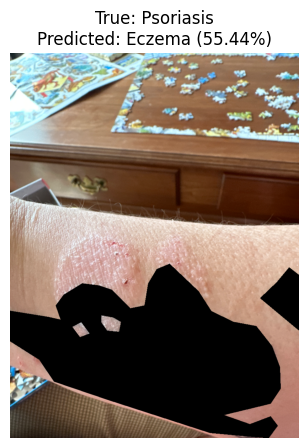

TRUE LABEL: Psoriasis
PREDICTED : Eczema
MODEL SCORE: 55.44%

ALL CLASS SCORES
Acne           : 23.64%
Eczema         : 55.44%
Folliculitis   : 11.75%
Psoriasis      : 9.17%


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# Use our selected Stage-1 model
final_common_model = best_stage1_model

# Pick one image from the untouched TEST set
sample = test_df.sample(
    n=1,
    random_state=7
).iloc[0]

image_path = sample["local_path"]
true_label = sample["label"]

# Load original image
img = Image.open(image_path).convert("RGB")

# Prepare exactly as during training
img_resized = img.resize((224, 224))

img_array = np.array(
    img_resized,
    dtype=np.float32
)

input_tensor = np.expand_dims(
    img_array,
    axis=0
)

# Predict
probabilities = final_common_model.predict(
    input_tensor,
    verbose=0
)[0]

pred_index = np.argmax(probabilities)
predicted_label = CLASS_NAMES[pred_index]
confidence = float(probabilities[pred_index])

# Display
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"True: {true_label}\n"
    f"Predicted: {predicted_label} "
    f"({confidence * 100:.2f}%)"
)
plt.show()

print("TRUE LABEL:", true_label)
print("PREDICTED :", predicted_label)
print(f"MODEL SCORE: {confidence * 100:.2f}%")

print("\nALL CLASS SCORES")
print("=" * 35)

for name, score in zip(
    CLASS_NAMES,
    probabilities
):
    print(
        f"{name:<15}: "
        f"{score * 100:.2f}%"
    )

In [34]:
COMMON_SKIN_THRESHOLD = 0.60

pred_index = np.argmax(probabilities)
predicted_label = CLASS_NAMES[pred_index]
confidence = float(probabilities[pred_index])

uncertain = confidence < COMMON_SKIN_THRESHOLD

if uncertain:
    final_result = "Uncertain"
else:
    final_result = predicted_label

print("DERMAWISE COMMON SKIN RESULT")
print("=" * 45)

print("Result:", final_result)
print("Highest-scoring category:", predicted_label)
print(f"Model score: {confidence * 100:.2f}%")
print("Uncertain:", uncertain)

print("\nALL CLASS SCORES")
for name, score in zip(CLASS_NAMES, probabilities):
    print(f"{name:<15}: {score * 100:.2f}%")

if uncertain:
    print(
        "\nThe model does not have sufficient confidence "
        "to provide a reliable category for this image."
    )

DERMAWISE COMMON SKIN RESULT
Result: Uncertain
Highest-scoring category: Eczema
Model score: 55.44%
Uncertain: True

ALL CLASS SCORES
Acne           : 23.64%
Eczema         : 55.44%
Folliculitis   : 11.75%
Psoriasis      : 9.17%

The model does not have sufficient confidence to provide a reliable category for this image.


Grad-CAM generated.
Heatmap shape: (7, 7)


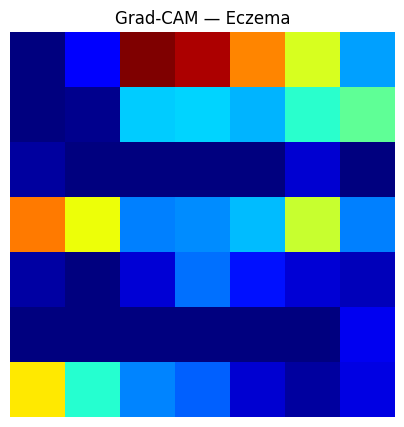

In [35]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Get nested EfficientNetB0
common_base_model = final_common_model.get_layer("efficientnetb0")

# Last convolutional activation
common_last_conv = common_base_model.get_layer("top_activation")

# Feature extractor
common_grad_model = tf.keras.Model(
    inputs=common_base_model.input,
    outputs=[
        common_last_conv.output,
        common_base_model.output
    ]
)

def generate_common_gradcam(model, image_tensor, class_index):

    with tf.GradientTape() as tape:

        # Dynamic augmentation layer
        x = model.layers[1](
            image_tensor,
            training=False
        )

        # EfficientNet feature extraction
        conv_output, x = common_grad_model(
            x,
            training=False
        )

        tape.watch(conv_output)

        # Remaining layers after EfficientNet
        for layer in model.layers[3:]:
            x = layer(x, training=False)

        class_score = x[:, class_index]

    gradients = tape.gradient(
        class_score,
        conv_output
    )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    conv_output = conv_output[0]

    heatmap = tf.reduce_sum(
        conv_output * pooled_gradients,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy()


# Generate Grad-CAM for highest-scoring category
heatmap = generate_common_gradcam(
    final_common_model,
    tf.convert_to_tensor(
        input_tensor,
        dtype=tf.float32
    ),
    pred_index
)

print("Grad-CAM generated.")
print("Heatmap shape:", heatmap.shape)

plt.figure(figsize=(5, 5))
plt.imshow(heatmap, cmap="jet")
plt.axis("off")
plt.title(
    f"Grad-CAM — {predicted_label}"
)
plt.show()

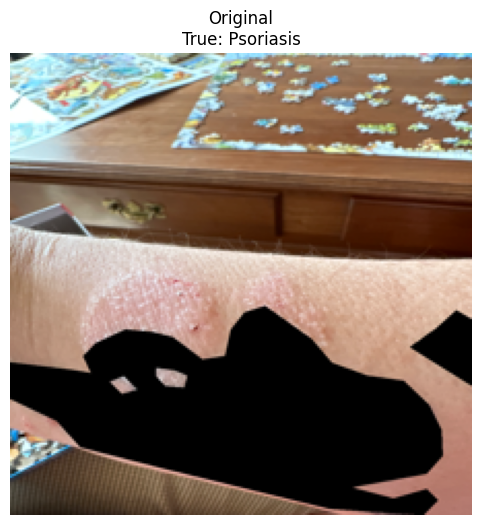

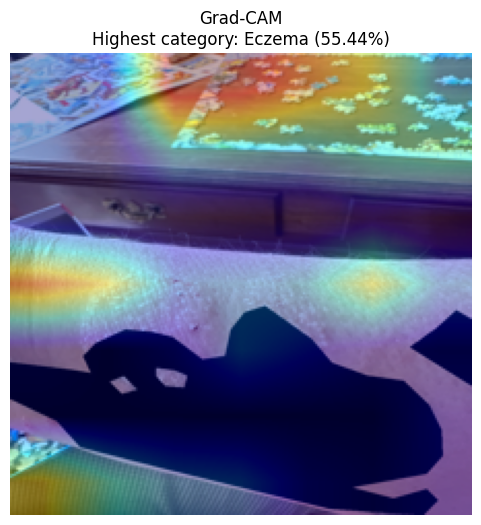

True label: Psoriasis
Highest category: Eczema
Model score: 55.44%
Final result: Uncertain


In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Original image as RGB
original = np.array(
    img.resize((224, 224))
)

# Resize 7x7 heatmap to image size
heatmap_resized = cv2.resize(
    heatmap,
    (224, 224)
)

# Convert to 0-255
heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

# Apply heatmap colors
colored_heatmap = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# OpenCV uses BGR -> convert to RGB
colored_heatmap = cv2.cvtColor(
    colored_heatmap,
    cv2.COLOR_BGR2RGB
)

# Overlay
overlay = (
    0.65 * original +
    0.35 * colored_heatmap
)

overlay = np.clip(
    overlay,
    0,
    255
).astype(np.uint8)

# Display original and Grad-CAM separately
plt.figure(figsize=(6, 6))
plt.imshow(original)
plt.axis("off")
plt.title(
    f"Original\nTrue: {true_label}"
)
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.axis("off")
plt.title(
    f"Grad-CAM\n"
    f"Highest category: {predicted_label} "
    f"({confidence * 100:.2f}%)"
)
plt.show()

print("True label:", true_label)
print("Highest category:", predicted_label)
print(f"Model score: {confidence * 100:.2f}%")
print(
    "Final result:",
    "Uncertain"
    if confidence < COMMON_SKIN_THRESHOLD
    else predicted_label
)

In [37]:
import shutil
from pathlib import Path

source_model = Path(
    "/content/drive/MyDrive/DermaWise/models/"
    "dermawise_common_skin_stage1_best.keras"
)

final_model = Path(
    "/content/drive/MyDrive/DermaWise/models/"
    "dermawise_common_skin_final.keras"
)

shutil.copy2(
    source_model,
    final_model
)

print("Final Common Skin model saved:")
print(final_model)

Final Common Skin model saved:
/content/drive/MyDrive/DermaWise/models/dermawise_common_skin_final.keras
